In [ ]:
#Ahmed Ali Alyousif/2230004696/8MA2.


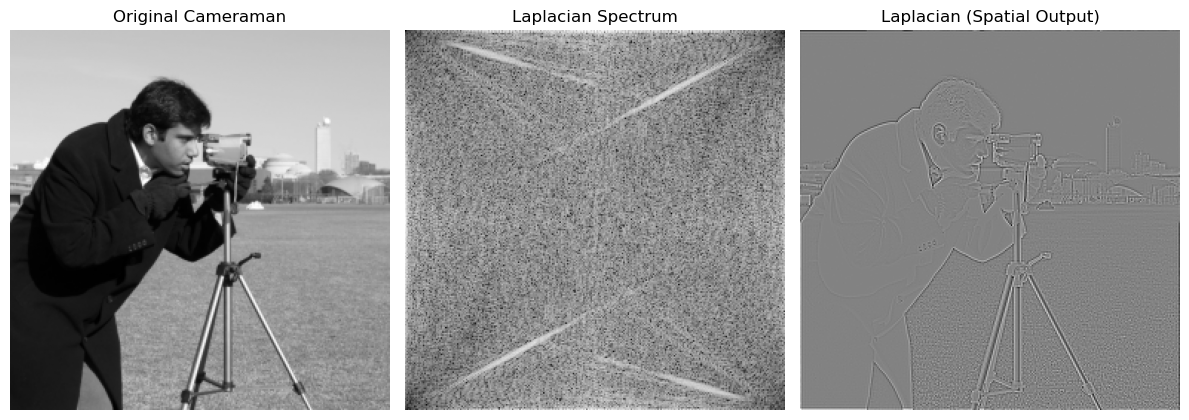

In [1]:
#The original picture.
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# Load and resize cameraman image
image = data.camera()
image = resize(image, (256, 256))

M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)


laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT to image
F = np.fft.fft2(image)

# Apply filter in frequency domain
F_lap = F * laplacian_filter


laplacian_image = np.fft.ifft2(F_lap).real

# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.tight_layout()
plt.show()

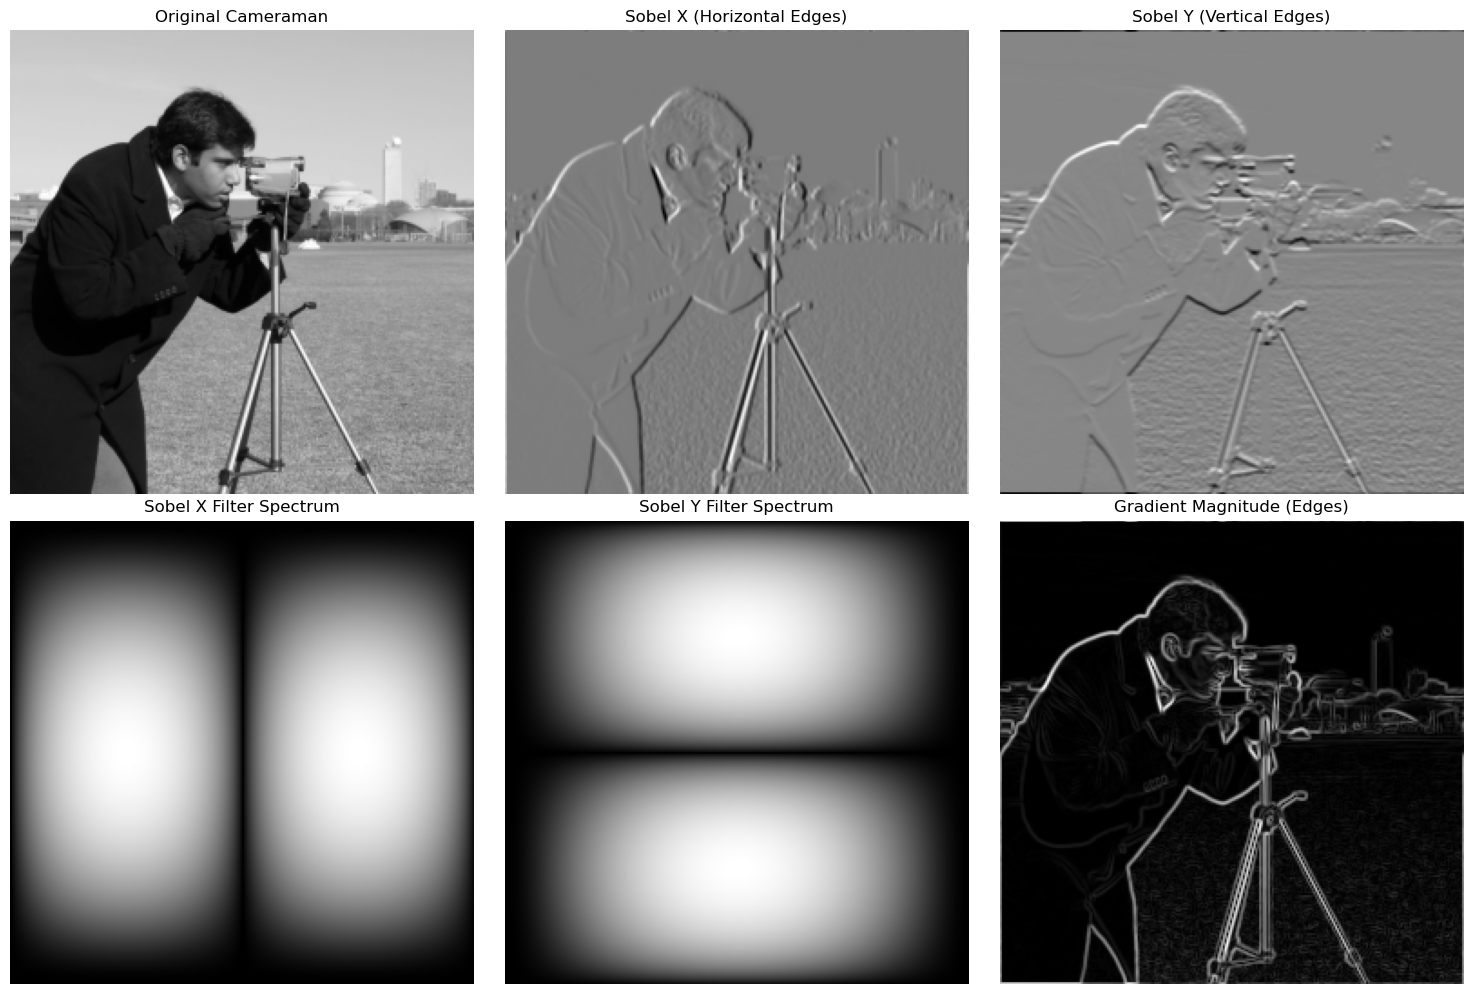

In [2]:
# Task 1: Sobel X and Y Filters in Frequency Domain
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

def center_embed_kernel(kernel, shape):
    """
    Embeds a spatial kernel into the center of a zero matrix of given shape
    and shifts it for frequency domain multiplication.
    """
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    # Find center coordinates of the padded image
    cy, cx = ph // 2, pw // 2
    
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, 
           cx - kw//2:cx - kw//2 + kw] = kernel
    
    # Shift so that kernel's (0,0) is at top-left before FFT
    return fft2(ifftshift(padded))

# Load and resize image
image = data.camera()
image = resize(image, (256, 256))

# Define Sobel kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])

# Get FFT of image
F_image = fft2(image)

# Get FFT of centered Sobel kernels
shape = image.shape
F_sobel_x = center_embed_kernel(sobel_x, shape)
F_sobel_y = center_embed_kernel(sobel_y, shape)

# Apply filters in frequency domain
F_x = F_image * F_sobel_x
F_y = F_image * F_sobel_y

# Inverse FFT to get spatial results
sobel_x_image = ifft2(F_x).real
sobel_y_image = ifft2(F_y).real

# Compute gradient magnitude
gradient_magnitude = np.sqrt(sobel_x_image**2 + sobel_y_image**2)

# Display results
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X (Horizontal Edges)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y (Vertical Edges)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.log(1 + np.abs(fftshift(F_sobel_x))), cmap='gray')
plt.title('Sobel X Filter Spectrum')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.log(1 + np.abs(fftshift(F_sobel_y))), cmap='gray')
plt.title('Sobel Y Filter Spectrum')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude (Edges)')
plt.axis('off')

plt.tight_layout()
plt.show()